<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# Desarrollo de modelos


Tiempo estimado: **30** minutos
    

## Objetivos

Al finalizar este laboratorio serás capaz de:

* Desarrollar modelos de predicción

<p>En esta sección desarrollaremos varios modelos que predecirán el precio del automóvil usando las variables o características. Es solo una estimación, pero debe darnos una idea objetiva de cuánto debería costar el automóvil.</p>

Algunas preguntas que queremos responder en este módulo
<ul>
    <li>¿Sé si el concesionario me ofrece un valor justo por mi vehículo en parte de pago?</li>
    <li>¿Sé si le puse un valor justo a mi automóvil?</li>
</ul>
<p>En el análisis de datos solemos usar el <b>desarrollo de modelos</b> para predecir observaciones futuras a partir de los datos que tenemos.</p>

<p>Un modelo nos ayuda a entender la relación exacta entre distintas variables y cómo se usan esas variables para predecir el resultado.</p>

<h4>Configuración</h4>

  Importa las bibliotecas:

In [ ]:
#instala la versión específica de las bibliotecas usadas en el laboratorio
#! mamba install pandas==1.3.3-y
#! mamba install numpy=1.21.2-y
#! mamba install sklearn=0.20.1-y

In [10]:
# piplite solo existe dentro de JupyterLite (Skills Network Labs).
# En un kernel local (Anaconda, VS Code) seaborn ya viene instalado.
try:
    import piplite
    await piplite.install('seaborn')
except ModuleNotFoundError:
    import importlib.util

    if importlib.util.find_spec("seaborn") is None:
        print("Falta seaborn: instálalo con  %pip install seaborn")
    else:
        print("Kernel local: seaborn ya está instalado, no hace falta piplite.")

Kernel local: seaborn ya está instalado, no hace falta piplite.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Carga los datos y guárdalos en el dataframe `df`:

In [12]:
# Funciona igual en JupyterLite (kernel del navegador) y en un kernel local
# (Anaconda, VS Code). Mantiene la firma asíncrona, así que las celdas que hacen
# "await download(...)" siguen funcionando sin cambios.
try:
    # Kernel del navegador: pyodide solo existe dentro de JupyterLite.
    from pyodide.http import pyfetch

    async def download(url, filename):
        response = await pyfetch(url)
        if response.status == 200:
            with open(filename, "wb") as f:
                f.write(await response.bytes())
        else:
            raise Exception(f"Download failed with status {response.status}")

except ModuleNotFoundError:
    # Kernel local (CPython): usamos la biblioteca estándar, sin pyodide.
    import asyncio
    from urllib.request import Request, urlopen

    def _descargar(url, filename):
        peticion = Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urlopen(peticion) as respuesta, open(filename, "wb") as f:
            f.write(respuesta.read())

    async def download(url, filename):
        # en un hilo aparte para no bloquear el bucle de eventos del cuaderno
        await asyncio.to_thread(_descargar, url, filename)

In [13]:
file_path= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv"

await download(file_path, "usedcars.csv")
file_name="usedcars.csv"

In [14]:
df = pd.read_csv(file_name)
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


>Nota: esta versión del laboratorio funciona en JupyterLite, que requiere descargar el conjunto de datos a la interfaz. Al trabajar con la versión descargada de este cuaderno en sus equipos locales (Jupyter Anaconda), los estudiantes pueden omitir simplemente los pasos anteriores y usar la URL directamente en la función pandas.read_csv(). Puedes descomentar y ejecutar las instrucciones de la celda de abajo.

In [ ]:
#filepath = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv"
#df = pd.read_csv(filepath, header=None)

<h2>1. Regresión lineal y regresión lineal múltiple</h2>

<h4>Regresión lineal</h4>


<p>Un ejemplo de modelo de datos que usaremos es:</p>
<b>Regresión lineal simple</b>

<br>
<p>La regresión lineal simple es un método que nos ayuda a entender la relación entre dos variables:</p>
<ul>
    <li>La variable predictora o independiente (X)</li>
    <li>La variable de respuesta o dependiente (la que queremos predecir) (Y)</li>
</ul>

<p>El resultado de la regresión lineal es una <b>función lineal</b> que predice la variable de respuesta (dependiente) en función de la variable predictora (independiente).</p>

$$
 Y: Variable de respuesta\\\\\\
 X: Variables predictoras
$$


 <b>Función lineal</b>
$$
Yhat = a + b  X
$$


<ul>
    <li>a es la <b>intersección</b> de la recta de regresión, es decir, el valor de Y cuando X es 0</li>
    <li>b es la <b>pendiente</b> de la recta de regresión, es decir, el valor en que cambia Y cuando X aumenta 1 unidad</li>
</ul>

<h4>Carguemos los módulos para la regresión lineal:</h4>

In [15]:
from sklearn.linear_model import LinearRegression

<h4>Crea el objeto de regresión lineal:</h4>

In [16]:
lm = LinearRegression()
lm

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


<h4>¿Cómo podría "highway-mpg" ayudarnos a predecir el precio del automóvil?</h4>

En este ejemplo queremos ver cómo highway-mpg nos ayuda a predecir el precio del automóvil.
Con la regresión lineal simple crearemos una función lineal con "highway-mpg" como variable predictora y "price" como variable de respuesta.

In [17]:
X = df[['highway-mpg']]
Y = df['price']

Ajusta el modelo lineal usando highway-mpg:

In [18]:
lm.fit(X,Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


  Podemos obtener una predicción:

In [19]:
Yhat=lm.predict(X)
Yhat[0:5]   

array([16236.50464347, 16236.50464347, 17058.23802179, 13771.3045085 ,
       20345.17153508])

<h4>¿Cuál es el valor de la intersección (a)?</h4>

In [20]:
lm.intercept_

np.float64(38423.3058581574)

<h4>¿Cuál es el valor de la pendiente (b)?</h4>

In [21]:
lm.coef_

array([-821.73337832])

<h3>¿Cuál es el modelo lineal estimado final que obtenemos?</h3>

Como vimos arriba, debemos obtener un modelo lineal final con la estructura:

$$
Yhat = a + b  X
$$


Al reemplazar los valores reales obtenemos:

<b>Precio</b> = 38423.31 - 821.73 x <b>highway-mpg</b>

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Pregunta #1 a): </h1>

<b>Crea un objeto de regresión lineal llamado "lm1".</b>
</div>

In [ ]:
# Escribe tu código a continuación y presiona Shift+Enter para ejecutar

<details><summary>Haz clic aquí para ver la solución</summary>

```python
lm1 = LinearRegression()
lm1
```

</details>

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Pregunta #1 b): </h1>

<b>¿Puedes entrenar el modelo usando "engine-size" como variable independiente y "price" como variable dependiente?</b>
</div>

In [ ]:
# Escribe tu código a continuación y presiona Shift+Enter para ejecutar

<details><summary>Haz clic aquí para ver la solución</summary>

```python
lm1.fit(df[['engine-size']], df[['price']])
lm1
```

</details>

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Pregunta #1 c):</h1>

<b>Encuentra la pendiente y la intersección del modelo.</b>
</div>

<h4>Pendiente</h4>

In [ ]:
# Escribe tu código a continuación y presiona Shift+Enter para ejecutar

<h4>Intersección</h4>

In [ ]:
# Escribe tu código a continuación y presiona Shift+Enter para ejecutar

<details><summary>Haz clic aquí para ver la solución</summary>

```python
# Pendiente 
lm1.coef_

# Intersección
lm1.intercept_
```

</details>

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Pregunta #1 d): </h1>

<b>¿Cuál es la ecuación de la recta de predicción? Puedes usar x e yhat, o "engine-size" y "price".</b>
</div>

In [ ]:
# Escribe tu código a continuación y presiona Shift+Enter para ejecutar

<details><summary>Haz clic aquí para ver la solución</summary>

```python
# usando X e Y  
Yhat=-7963.34 + 166.86*X

Price=-7963.34 + 166.86*df['engine-size']

```

</details>

<h4>Regresión lineal múltiple</h4>

<p>¿Y si queremos predecir el precio del automóvil usando más de una variable?</p>

<p>Si queremos usar más variables en nuestro modelo para predecir el precio del automóvil, podemos usar la <b>regresión lineal múltiple</b>.
La regresión lineal múltiple es muy parecida a la regresión lineal simple, pero este método se usa para explicar la relación entre una variable de respuesta continua (dependiente) y <b>dos o más</b> variables predictoras (independientes).
La mayoría de los modelos de regresión del mundo real incluyen varios predictores. Ilustraremos la estructura con cuatro variables predictoras, pero estos resultados se generalizan a cualquier número entero:</p>

$$
Y: Variable de respuesta\\\\\\
X_1 :Variable\ predictora \ 1\\
X_2: Variable\ predictora \ 2\\
X_3: Variable\ predictora \ 3\\
X_4: Variable\ predictora \ 4\\
$$


$$
a: intersección\\\\\\
b_1 :coeficientes\ de\ la\ variable \ 1\\
b_2: coeficientes\ de\ la\ variable \ 2\\
b_3: coeficientes\ de\ la\ variable \ 3\\
b_4: coeficientes\ de\ la\ variable \ 4\\
$$


La ecuación está dada por:

$$
Yhat = a + b_1 X_1 + b_2 X_2 + b_3 X_3 + b_4 X_4
$$


<p>De la sección anterior sabemos que otros buenos predictores del precio podrían ser:</p>
<ul>
    <li>Horsepower (potencia)</li>
    <li>Curb-weight (peso en vacío)</li>
    <li>Engine-size (tamaño del motor)</li>
    <li>Highway-mpg (rendimiento en carretera)</li>
</ul>
Desarrollemos un modelo usando estas variables como variables predictoras.

In [22]:
Z = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]

Ajusta el modelo lineal usando las cuatro variables mencionadas arriba.

In [23]:
lm.fit(Z, df['price'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


¿Cuál es el valor de la intersección (a)?

In [24]:
lm.intercept_

np.float64(-15806.62462632923)

¿Cuáles son los valores de los coeficientes (b1, b2, b3, b4)?

In [25]:
lm.coef_

array([53.49574423,  4.70770099, 81.53026382, 36.05748882])

  ¿Cuál es el modelo lineal estimado final que obtenemos?

Como vimos arriba, debemos obtener una función lineal final con la estructura:

$$
Yhat = a + b_1 X_1 + b_2 X_2 + b_3 X_3 + b_4 X_4
$$

¿Cuál es la función lineal que obtenemos en este ejemplo?

<b>Precio</b> = -15678.742628061467 + 52.65851272 x <b>horsepower</b> + 4.69878948 x <b>curb-weight</b> + 81.95906216 x <b>engine-size</b> + 33.58258185 x <b>highway-mpg</b>

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Pregunta #2 a): </h1>
Crea y entrena un modelo de regresión lineal múltiple "lm2" donde la variable de respuesta sea "price" y las variables predictoras sean "normalized-losses" y "highway-mpg".
</div>

In [ ]:
# Escribe tu código a continuación y presiona Shift+Enter para ejecutar

<details><summary>Haz clic aquí para ver la solución</summary>

```python
lm2 = LinearRegression()
lm2.fit(df[['normalized-losses' , 'highway-mpg']],df['price'])


```

</details>

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Pregunta #2 b): </h1>
<b>Encuentra el coeficiente del modelo.</b>
</div>

In [ ]:
# Escribe tu código a continuación y presiona Shift+Enter para ejecutar

<details><summary>Haz clic aquí para ver la solución</summary>

```python
lm2.coef_

```

</details>

<h2>2. Evaluación del modelo mediante visualización</h2>

Ahora que hemos desarrollado algunos modelos, ¿cómo los evaluamos y elegimos el mejor? Una forma de hacerlo es mediante una visualización.

Importa el paquete de visualización, seaborn:

In [26]:
# importa el paquete de visualización: seaborn
import seaborn as sns
%matplotlib inline

<h3>Gráfico de regresión</h3>

<p>En la regresión lineal simple, una excelente forma de visualizar el ajuste de nuestro modelo es usar los <b>gráficos de regresión</b>.</p>

<p>Este gráfico muestra una combinación de una nube de puntos dispersos (un <b>diagrama de dispersión</b>) con la recta de <b>regresión lineal</b> ajustada que atraviesa los datos. Nos da una estimación razonable de la relación entre las dos variables, de la fuerza de la correlación y de su dirección (correlación positiva o negativa).</p>

  Visualicemos **highway-mpg** como posible variable predictora del precio:

(0.0, 48166.74014216062)

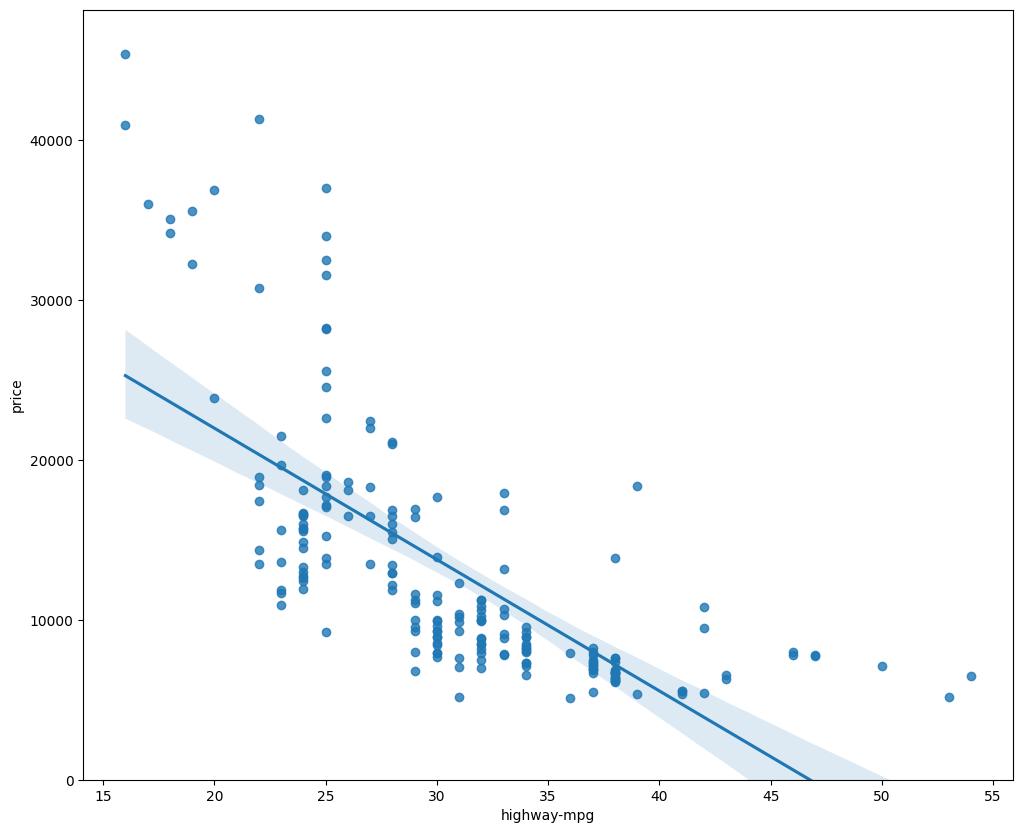

In [27]:
width = 12
height = 10
plt.figure(figsize=(width, height))
sns.regplot(x="highway-mpg", y="price", data=df)
plt.ylim(0,)

<p>En este gráfico vemos que el precio está correlacionado negativamente con highway-mpg, porque la pendiente de la regresión es negativa.

Al observar un gráfico de regresión conviene fijarse en cuán dispersos están los puntos alrededor de la recta de regresión. Esto da una buena indicación de la varianza de los datos y de si un modelo lineal sería el mejor ajuste o no. Si los datos se alejan mucho de la recta, este modelo lineal podría no ser el mejor para esos datos.

Comparemos este gráfico con el gráfico de regresión de "peak-rpm".</p>

(0.0, 47414.1)

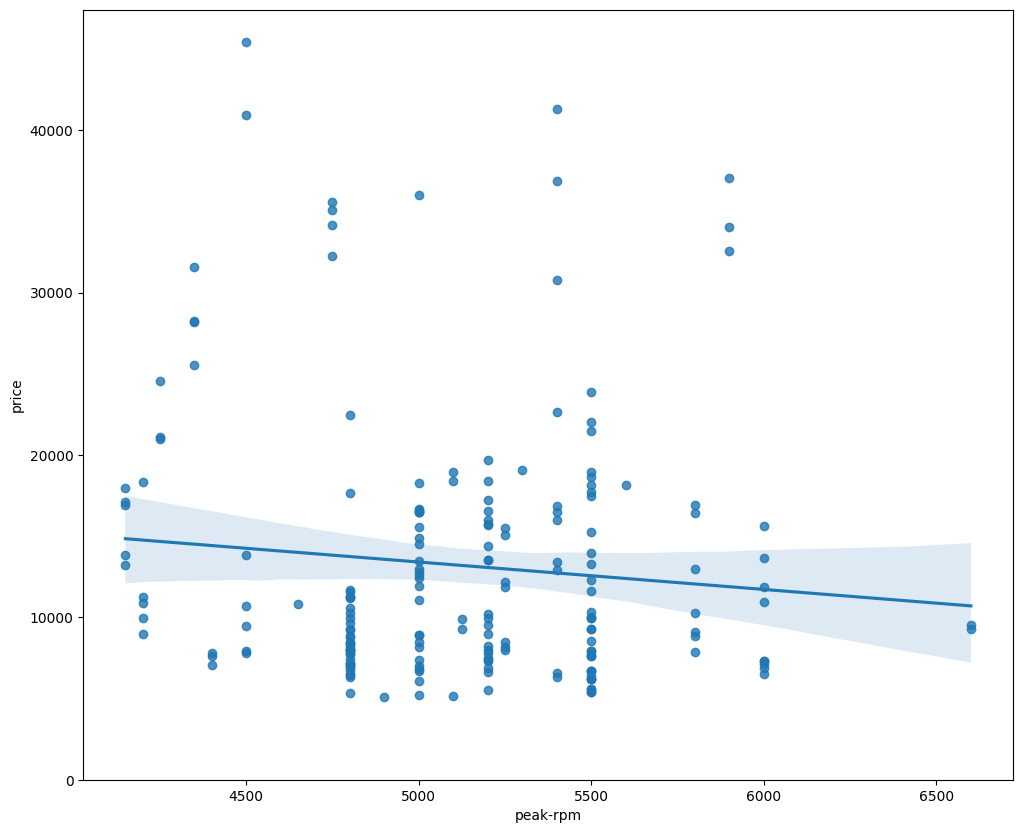

In [28]:
plt.figure(figsize=(width, height))
sns.regplot(x="peak-rpm", y="price", data=df)
plt.ylim(0,)

<p>Al comparar los gráficos de regresión de "peak-rpm" y "highway-mpg" vemos que los puntos de "highway-mpg" están mucho más cerca de la recta generada y, en promedio, disminuyen. Los puntos de "peak-rpm" están más dispersos alrededor de la recta predicha y es mucho más difícil determinar si disminuyen o aumentan a medida que "peak-rpm" aumenta.</p>

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Pregunta #3:</h1>
<b>De acuerdo con los gráficos de regresión anteriores, ¿"peak-rpm" o "highway-mpg" está más fuertemente correlacionada con "price"? Usa el método ".corr()" para verificar tu respuesta.</b>
</div>

In [ ]:
# Escribe tu código a continuación y presiona Shift+Enter para ejecutar

<details><summary>Haz clic aquí para ver la solución</summary>

```python
# La variable "highway-mpg" tiene una correlación más fuerte con "price": es aproximadamente -0.704692, frente a "peak-rpm", que es aproximadamente -0.101616. Puedes verificarlo con el siguiente comando:

df[["peak-rpm","highway-mpg","price"]].corr()

```

</details>

<h3>Gráfico de residuos</h3>

<p>Una buena forma de visualizar la varianza de los datos es usar un gráfico de residuos.</p>

<p>¿Qué es un <b>residuo</b>?</p>

<p>La diferencia entre el valor observado (y) y el valor predicho (Yhat) se llama residuo (e). Cuando miramos un gráfico de regresión, el residuo es la distancia desde el punto de datos hasta la recta de regresión ajustada.</p>

<p>¿Y qué es un <b>gráfico de residuos</b>?</p>

<p>Un gráfico de residuos es una gráfica que muestra los residuos en el eje vertical y y la variable independiente en el eje horizontal x.</p>

<p>¿En qué nos fijamos al mirar un gráfico de residuos?</p>

<p>Nos fijamos en la dispersión de los residuos:</p>

<p>- Si los puntos de un gráfico de residuos están <b>dispersos aleatoriamente alrededor del eje x</b>, entonces un <b>modelo lineal es apropiado</b> para los datos.

¿Por qué? Que los residuos estén dispersos aleatoriamente significa que la varianza es constante y, por lo tanto, el modelo lineal es un buen ajuste para estos datos.</p>

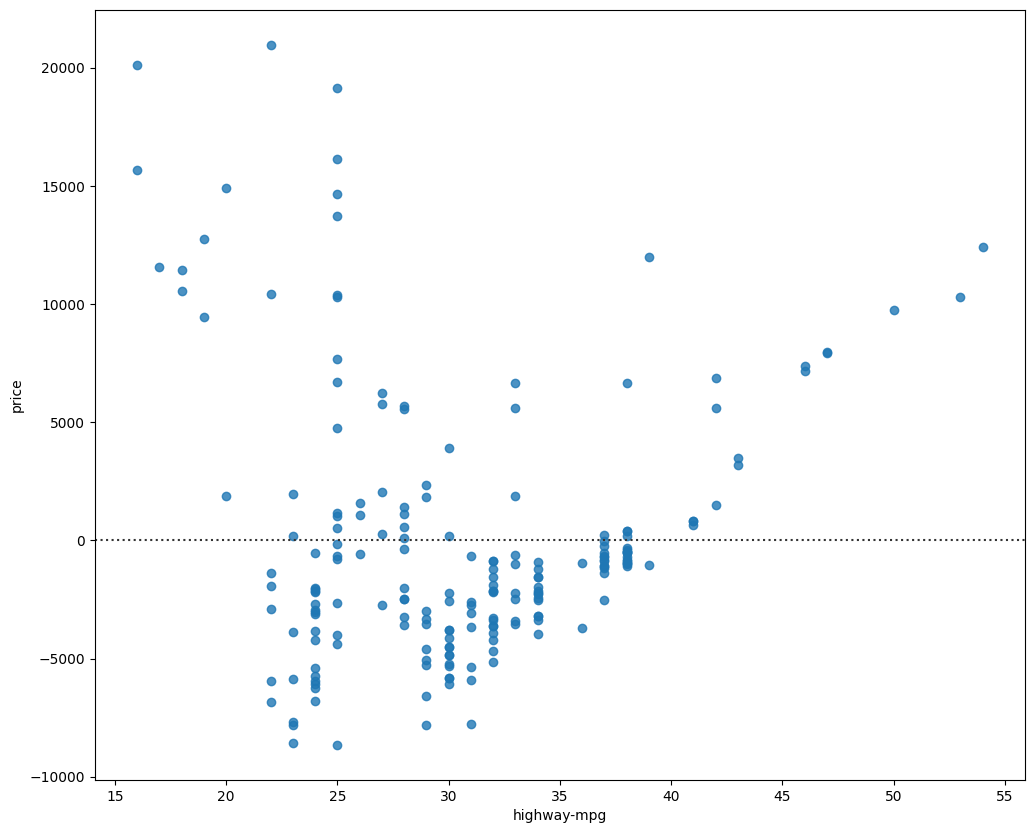

In [29]:
width = 12
height = 10
plt.figure(figsize=(width, height))
sns.residplot(x=df['highway-mpg'], y=df['price'])
plt.show()

<i>¿Qué nos dice este gráfico?</i>

<p>En este gráfico de residuos vemos que los residuos no están dispersos aleatoriamente alrededor del eje x, lo que nos hace pensar que tal vez un modelo no lineal sea más apropiado para estos datos.</p>

<h3>Regresión lineal múltiple</h3>

<p>¿Cómo visualizamos un modelo de regresión lineal múltiple? Esto se complica un poco, porque no se puede visualizar con un gráfico de regresión ni de residuos.</p>

<p>Una forma de examinar el ajuste del modelo es mirar el <b>gráfico de distribución</b>. Podemos ver la distribución de los valores ajustados que produce el modelo y compararla con la distribución de los valores reales.</p>

Primero hagamos una predicción:

In [30]:
Y_hat = lm.predict(Z)

C:\Users\CARLOS\AppData\Local\Temp\ipykernel_25364\4196657742.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
C:\Users\CARLOS\AppData\Local\Temp\ipykernel_25364\4196657742.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

 

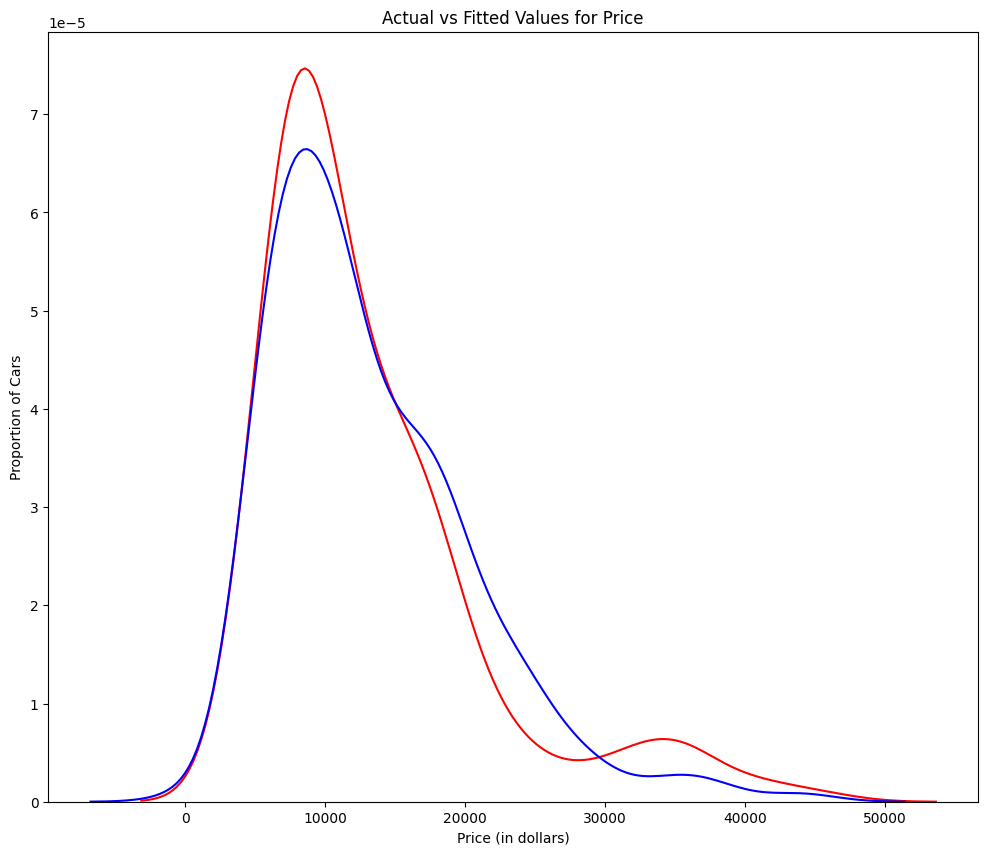

In [31]:
plt.figure(figsize=(width, height))


ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
sns.distplot(Y_hat, hist=False, color="b", label="Fitted Values" , ax=ax1)


plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')

plt.show()
plt.close()

<p>Vemos que los valores ajustados están razonablemente cerca de los valores reales, ya que ambas distribuciones se superponen un poco. Sin embargo, sin duda hay margen de mejora.</p>

<h2>3. Regresión polinómica y flujos de trabajo (pipelines)</h2>

<p>La <b>regresión polinómica</b> es un caso particular del modelo general de regresión lineal o de los modelos de regresión lineal múltiple.</p> 
<p>Obtenemos relaciones no lineales elevando al cuadrado o incluyendo términos de orden superior de las variables predictoras.</p>

<p>Existen distintos órdenes de regresión polinómica:</p>

<center><b>Cuadrática - segundo orden</b></center>
$$
Yhat = a + b_1 X +b_2 X^2 
$$


<center><b>Cúbica - tercer orden</b></center>
$$
Yhat = a + b_1 X +b_2 X^2 +b_3 X^3\\\\\\
$$


<center><b>Orden superior</b>:</center>
$$
Y = a + b_1 X +b_2 X^2 +b_3 X^3 ....\\
$$


<p>Vimos antes que un modelo lineal no daba el mejor ajuste usando "highway-mpg" como variable predictora. Veamos si podemos ajustar un modelo polinómico a los datos en su lugar.</p>

<p>Usaremos la siguiente función para graficar los datos:</p>

In [32]:
def PlotPolly(model, independent_variable, dependent_variabble, Name):
    x_new = np.linspace(15, 55, 100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variabble, '.', x_new, y_new, '-')
    plt.title('Polynomial Fit with Matplotlib for Price ~ Length')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of Cars')

    plt.show()
    plt.close()

Obtengamos las variables:

In [33]:
x = df['highway-mpg']
y = df['price']

Ajustemos el polinomio con la función <b>polyfit</b> y luego usemos la función <b>poly1d</b> para mostrar la función polinómica.

In [34]:
# Aquí usamos un polinomio de tercer orden (cúbico) 
f = np.polyfit(x, y, 3)
p = np.poly1d(f)
print(p)

        3         2
-1.557 x + 204.8 x - 8965 x + 1.379e+05


  Grafiquemos la función:

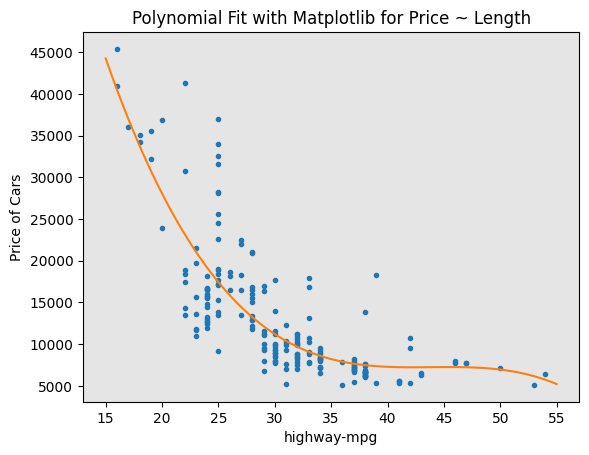

In [35]:
PlotPolly(p, x, y, 'highway-mpg')

In [36]:
np.polyfit(x, y, 3)

array([-1.55663829e+00,  2.04754306e+02, -8.96543312e+03,  1.37923594e+05])

<p>Ya podemos ver en la gráfica que este modelo polinómico se comporta mejor que el modelo lineal. Esto se debe a que la función polinómica generada "acierta" en más puntos de datos.</p>

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Pregunta #4:</h1>
<b>Crea un modelo polinómico de orden 11 con las variables x e y anteriores.</b>
</div>

In [ ]:
# Escribe tu código a continuación y presiona Shift+Enter para ejecutar

<details><summary>Haz clic aquí para ver la solución</summary>

```python
# Aquí usamos un polinomio de orden 11
f1 = np.polyfit(x, y, 11)
p1 = np.poly1d(f1)
print(p1)
PlotPolly(p1,x,y, 'Highway MPG')

```

</details>

<p>La expresión analítica de una función polinómica multivariada se complica. Por ejemplo, la expresión de un polinomio de segundo orden (grado=2) con dos variables está dada por:</p>

$$
Yhat = a + b_1 X_1 +b_2 X_2 +b_3 X_1 X_2+b_4 X_1^2+b_5 X_2^2
$$


Podemos hacer una transformación polinómica sobre varias características. Primero importamos el módulo:

In [37]:
from sklearn.preprocessing import PolynomialFeatures

Creamos un objeto <b>PolynomialFeatures</b> de grado 2: 

In [38]:
pr=PolynomialFeatures(degree=2)
pr

,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [39]:
Z_pr=pr.fit_transform(Z)

En los datos originales hay 201 muestras y 4 características.

In [40]:
Z.shape

(201, 4)

Después de la transformación hay 201 muestras y 15 características.

In [41]:
Z_pr.shape

(201, 15)

<h2>Flujo de trabajo (pipeline)</h2>

<p>Los flujos de trabajo de datos simplifican los pasos de procesamiento de los datos. Usamos el módulo <b>Pipeline</b> para crear un flujo de trabajo. También usamos <b>StandardScaler</b> como un paso del flujo.</p>

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

Creamos el flujo de trabajo con una lista de tuplas que incluye el nombre del modelo o estimador y su constructor correspondiente.

In [43]:
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model',LinearRegression())]

Pasamos la lista como argumento al constructor del flujo de trabajo:

In [44]:
pipe=Pipeline(Input)
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('polynomial', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


Primero convertimos el tipo de datos de Z a float para evitar advertencias de conversión que pueden aparecer porque StandardScaler recibe entradas de tipo float.

Luego podemos normalizar los datos, hacer la transformación y ajustar el modelo al mismo tiempo.

In [45]:
Z = Z.astype(float)
pipe.fit(Z,y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('polynomial', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


  De forma similar, podemos normalizar los datos, hacer la transformación y producir una predicción al mismo tiempo.

In [46]:
ypipe=pipe.predict(Z)
ypipe[0:4]

array([13102.74784201, 13102.74784201, 18225.54572197, 10390.29636555])

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Pregunta #5:</h1>
<b>Crea un flujo de trabajo que estandarice los datos y luego produzca una predicción con un modelo de regresión lineal usando las características Z y la variable objetivo y.</b>
</div>

In [ ]:
# Escribe tu código a continuación y presiona Shift+Enter para ejecutar

<details><summary>Haz clic aquí para ver la solución</summary>

```python
Input=[('scale',StandardScaler()),('model',LinearRegression())]

pipe=Pipeline(Input)

pipe.fit(Z,y)

ypipe=pipe.predict(Z)
ypipe[0:10]

```

</details>

<h2>4. Medidas de evaluación dentro de la muestra</h2>

<p>Al evaluar nuestros modelos no solo queremos visualizar los resultados: también queremos una medida cuantitativa que determine qué tan preciso es el modelo.</p>

<p>Dos medidas muy importantes que se usan con frecuencia en estadística para determinar la precisión de un modelo son:</p>
<ul>
    <li><b>R^2 / R-cuadrado</b></li>
    <li><b>Error cuadrático medio (MSE)</b></li>
</ul>
    
<b>R-cuadrado</b>

<p>El R-cuadrado, también conocido como coeficiente de determinación, es una medida que indica qué tan cerca están los datos de la recta de regresión ajustada.</p>
    
<p>El valor del R-cuadrado es el porcentaje de la variación de la variable de respuesta (y) que explica un modelo lineal.</p>



<b>Error cuadrático medio (MSE)</b>

<p>El error cuadrático medio mide el promedio de los cuadrados de los errores. Es decir, de la diferencia entre el valor real (y) y el valor estimado (ŷ).</p>

<h3>Modelo 1: regresión lineal simple</h3>

Calculemos el R^2:

In [ ]:
#highway_mpg_fit
lm.fit(X, Y)
# Halla el R^2
print('El R-cuadrado es: ', lm.score(X, Y))

Podemos decir que este modelo lineal simple "horsepower_fit" explica aproximadamente el 49.659% de la variación del precio.

Calculemos el MSE:

Podemos predecir la salida, es decir "yhat", con el método predict, donde X es la variable de entrada:

In [ ]:
Yhat=lm.predict(X)
print('La salida de los primeros cuatro valores predichos es: ', Yhat[0:4])

Importemos la función <b>mean_squared_error</b> del módulo <b>metrics</b>:

In [ ]:
from sklearn.metrics import mean_squared_error

Podemos comparar los resultados predichos con los resultados reales:

In [ ]:
mse = mean_squared_error(df['price'], Yhat)
print('El error cuadrático medio del precio y el valor predicho es: ', mse)

<h3>Modelo 2: regresión lineal múltiple</h3>

Calculemos el R^2:

In [ ]:
# ajusta el modelo 
lm.fit(Z, df['price'])
# Halla el R^2
print('El R-cuadrado es: ', lm.score(Z, df['price']))

Podemos decir que esta regresión lineal múltiple "multi_fit" explica aproximadamente el 80.896 % de la variación del precio.

Calculemos el MSE.

Producimos una predicción:

In [ ]:
Y_predict_multifit = lm.predict(Z)

Comparamos los resultados predichos con los resultados reales:

In [ ]:
print('El error cuadrático medio del precio y el valor predicho usando multifit es: ', \
      mean_squared_error(df['price'], Y_predict_multifit))

<h3>Modelo 3: ajuste polinómico</h3>

Calculemos el R^2.

Importemos la función <b>r2_score</b> del módulo <b>metrics</b>, ya que estamos usando una función distinta.

In [ ]:
from sklearn.metrics import r2_score

Aplicamos la función para obtener el valor de R^2:

In [ ]:
r_squared = r2_score(y, p(x))
print('El valor de R-cuadrado es: ', r_squared)

Podemos decir que este ajuste polinómico explica aproximadamente el 67.419 % de la variación del precio.

<h3>MSE</h3>


También podemos calcular el MSE:

In [ ]:
mean_squared_error(df['price'], p(x))

<h2>5. Predicción y toma de decisiones</h2>
<h3>Predicción</h3>

<p>En la sección anterior entrenamos el modelo con el método <b>fit</b>. Ahora usaremos el método <b>predict</b> para producir una predicción. Importemos <b>pyplot</b> para graficar; también usaremos algunas funciones de numpy.</p>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline 

Crea una nueva entrada:

In [ ]:
new_input=np.arange(1, 100, 1).reshape(-1, 1)

  Ajusta el modelo:

In [ ]:
lm.fit(X, Y)
lm

Produce una predicción:

In [ ]:
yhat=lm.predict(new_input)
yhat[0:5]

Podemos graficar los datos:

In [ ]:
plt.plot(new_input, yhat)
plt.show()

<h3>Toma de decisiones: determinar un buen ajuste del modelo</h3>

<p>Ahora que hemos visualizado los distintos modelos y calculado los valores de R-cuadrado y MSE de los ajustes, ¿cómo determinamos un buen ajuste de modelo?
<ul>
    <li><i>¿Qué es un buen valor de R-cuadrado?</i></li>
</ul>
</p>

<p>Al comparar modelos, <b>el modelo con el valor de R-cuadrado más alto es el que mejor se ajusta</b> a los datos.
<ul>
    <li><i>¿Qué es un buen MSE?</i></li>
</ul>
</p>

<p>Al comparar modelos, <b>el modelo con el menor valor de MSE es el que mejor se ajusta</b> a los datos.</p>


<h4>Veamos los valores de los distintos modelos.</h4>
<p>Regresión lineal simple: usando Highway-mpg como variable predictora del precio.
<ul>
    <li>R-cuadrado: 0.49659118843391759</li>
    <li>MSE: 3.16 x10^7</li>
</ul>
</p>
    
<p>Regresión lineal múltiple: usando Horsepower, Curb-weight, Engine-size y Highway-mpg como variables predictoras del precio.
<ul>
    <li>R-cuadrado: 0.80896354913783497</li>
    <li>MSE: 1.2 x10^7</li>
</ul>
</p>
    
<p>Ajuste polinómico: usando Highway-mpg como variable predictora del precio.
<ul>
    <li>R-cuadrado: 0.6741946663906514</li>
    <li>MSE: 2.05 x 10^7</li>
</ul>
</p>

<h3>Modelo de regresión lineal simple (SLR) frente al modelo de regresión lineal múltiple (MLR)</h3>

<p>Por lo general, cuantas más variables tengas, mejor predecirá tu modelo, pero esto no siempre es cierto. A veces no tienes suficientes datos, puedes encontrarte con problemas numéricos, o muchas de las variables pueden no ser útiles e incluso actuar como ruido. Por eso siempre conviene revisar el MSE y el R^2.</p>

<p>Para comparar los resultados de los modelos MLR y SLR miramos una combinación del R-cuadrado y del MSE para llegar a la mejor conclusión sobre el ajuste del modelo.
<ul>
    <li><b>MSE</b>: el MSE del SLR es 3.16x10^7, mientras que el MLR tiene un MSE de 1.2 x10^7. El MSE del MLR es mucho menor.</li>
    <li><b>R-cuadrado</b>: en este caso también vemos una gran diferencia entre el R-cuadrado del SLR y el del MLR. El R-cuadrado del SLR (~0.497) es muy pequeño comparado con el del MLR (~0.809).</li>
</ul>
</p>

Este R-cuadrado, junto con el MSE, muestra que el MLR parece el modelo con mejor ajuste en este caso, comparado con el SLR.

<h3>Modelo lineal simple (SLR) frente al ajuste polinómico</h3>

<ul>
    <li><b>MSE</b>: vemos que el ajuste polinómico redujo el MSE, ya que este MSE es menor que el del SLR.</li> 
    <li><b>R-cuadrado</b>: el R-cuadrado del ajuste polinómico es mayor que el del SLR, así que el ajuste polinómico también elevó bastante el R-cuadrado.</li>
</ul>
<p>Como el ajuste polinómico dio un MSE menor y un R-cuadrado mayor, podemos concluir que fue un modelo con mejor ajuste que la regresión lineal simple para predecir "price" con "highway-mpg" como variable predictora.</p>

<h3>Regresión lineal múltiple (MLR) frente al ajuste polinómico</h3>

<ul>
    <li><b>MSE</b>: el MSE del MLR es menor que el MSE del ajuste polinómico.</li>
    <li><b>R-cuadrado</b>: el R-cuadrado del MLR también es mucho mayor que el del ajuste polinómico.</li>
</ul>

<h2>Conclusión</h2>

<p>Al comparar estos tres modelos concluimos que <b>el modelo MLR es el mejor</b> para predecir el precio a partir de nuestro conjunto de datos. Este resultado tiene sentido, porque tenemos 27 variables en total y sabemos que más de una de ellas son posibles predictoras del precio final del automóvil.</p>

### ¡Gracias por completar este laboratorio!


## Autor

<a href="https://www.linkedin.com/in/joseph-s-50398b136/" target="_blank">Joseph Santarcangelo</a>


### Otros colaboradores

<a href="https://www.linkedin.com/in/mahdi-noorian-58219234/" target="_blank">Mahdi Noorian PhD</a>

Bahare Talayian

Eric Xiao

Steven Dong

Parizad

Hima Vasudevan

<a href="https://www.linkedin.com/in/fiorellawever/" target="_blank">Fiorella Wenver</a>

<a href=" https://www.linkedin.com/in/yi-leng-yao-84451275/ " target="_blank" >Yi Yao</a>.

<a href="https://www.coursera.org/instructor/~129186572" target = "_blank" > Abhishek Gagneja</a>

## <h3 align="center"> © IBM Corporation 2023. Todos los derechos reservados. <h3/>
<!--

## Registro de cambios


|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
|---|---|---|---|
| 2023-09-28 | 2.3 | Abhishek Gagneja | Updated instructions |
| 2020-10-30  | 2.2  | Lakshmi  |Changed url of csv  |
| 2020-09-09  | 2.1  | Lakshmi  | Fixes made in Polynomial Regression Equations  |
| 2020-08-27  | 2.0  | Lavanya  |  Moved lab to course repo in GitLab  |



--!>
<hr>

